In [2]:
import spatialdata as sd
import spatialdata_plot
import matplotlib.pyplot as plt

/home/stefano/miniconda3/envs/analysis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_path = "/home/stefano/Documents/Spatial-Transcriptomic/data/blocco1_sham"
sdata = sd.read_zarr(data_path)
sdata

/tmp/ipykernel_35762/1828072172.py:2: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr(data_path)
/home/stefano/miniconda3/envs/analysis/lib/python3.11/site-packages/zarr/core/group.py:3535: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


SpatialData object, with associated Zarr store: /home/stefano/Documents/Spatial-Transcriptomic/data/blocco1_sham
├── Images
│     ├── 'blocco1_hires_image': DataArray[cyx] (3, 1849, 4270)
│     ├── 'blocco1_lowres_image': DataArray[cyx] (3, 185, 427)
│     └── 'fluo_image': DataTree[cyx] (3, 7000, 16166), (3, 3500, 8083), (3, 1750, 4041), (3, 875, 2020)
├── Shapes
│     ├── 'GFP_poly': GeoDataFrame shape: (2, 5) (2D shapes)
│     ├── 'blocco1_square_008um': GeoDataFrame shape: (171116, 2) (2D shapes)
│     ├── 'blocco1_square_016um': GeoDataFrame shape: (44363, 1) (2D shapes)
│     ├── 'intissue_008um': GeoDataFrame shape: (95232, 3) (2D shapes)
│     └── 'intissue_poly': GeoDataFrame shape: (1, 5) (2D shapes)
└── Tables
      ├── 'filtered': AnnData (95232, 32285)
      ├── 'final_table': AnnData (95514, 32285)
      ├── 'square_008um': AnnData (95514, 32285)
      └── 'square_016um': AnnData (44363, 32285)
with coordinate systems:
    ▸ 'blocco1', with elements:
        blocco1_hires

INFO     Rasterizing image for faster rendering.                                                                   


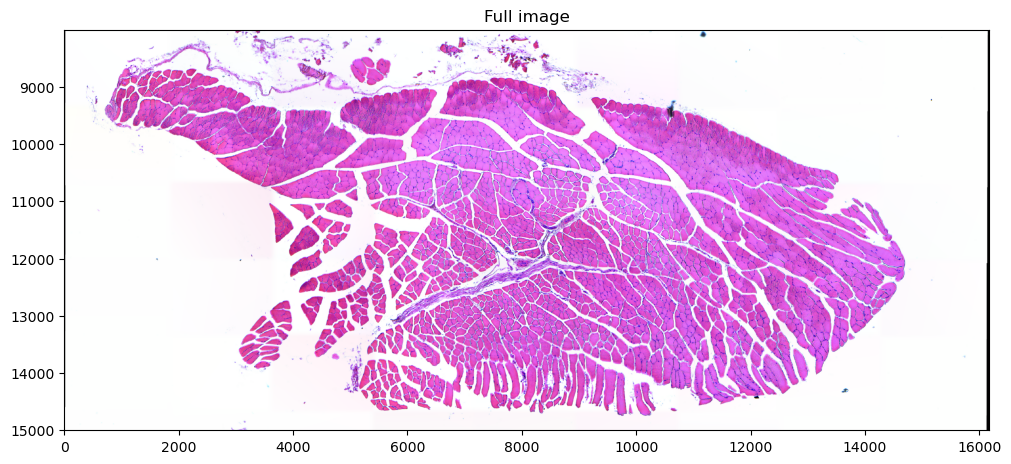

In [34]:
#plot the data
sdata.pl.render_images("blocco1_hires_image").pl.show(coordinate_systems = "blocco1", title="Full image", figsize=(10,10))


INFO     Rasterizing image for faster rendering.                                                                   


/home/stefano/miniconda3/envs/analysis/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:170: UserWarning: The table is annotating 'intissue_008um', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


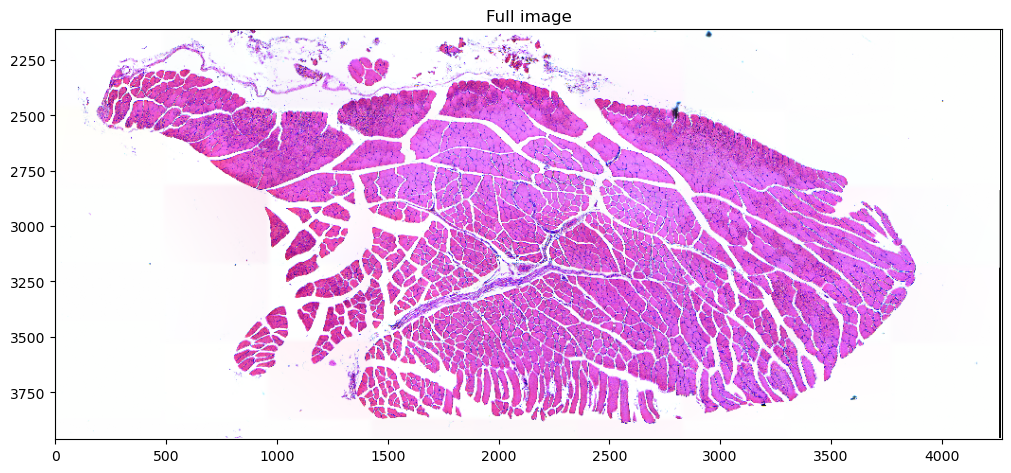

In [60]:
#plot the data
sdata.pl.render_images("blocco1_hires_image").pl.show(coordinate_systems = "blocco1_downscaled_hires", title="Full image", figsize=(10,10))


In [9]:
sdata

/home/stefano/miniconda3/envs/analysis/lib/python3.11/site-packages/zarr/core/group.py:3535: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


SpatialData object, with associated Zarr store: /home/stefano/Documents/Spatial-Transcriptomic/data/blocco1_sham
├── Images
│     ├── 'blocco1_hires_image': DataArray[cyx] (3, 1849, 4270)
│     ├── 'blocco1_lowres_image': DataArray[cyx] (3, 185, 427)
│     └── 'fluo_image': DataTree[cyx] (3, 7000, 16166), (3, 3500, 8083), (3, 1750, 4041), (3, 875, 2020)
├── Shapes
│     ├── 'GFP_poly': GeoDataFrame shape: (2, 5) (2D shapes)
│     ├── 'blocco1_square_008um': GeoDataFrame shape: (171116, 2) (2D shapes)
│     ├── 'blocco1_square_016um': GeoDataFrame shape: (44363, 1) (2D shapes)
│     ├── 'intissue_008um': GeoDataFrame shape: (95232, 3) (2D shapes)
│     └── 'intissue_poly': GeoDataFrame shape: (1, 5) (2D shapes)
└── Tables
      ├── 'filtered': AnnData (95232, 32285)
      ├── 'final_table': AnnData (95514, 32285)
      ├── 'square_008um': AnnData (95514, 32285)
      └── 'square_016um': AnnData (44363, 32285)
with coordinate systems:
    ▸ 'blocco1', with elements:
        blocco1_hires

# Crop image with Napari
Try to crop a portion of the image with napari and then focus with the analysis on the cropped image

In [4]:
import napari
import numpy as np

from spatialdata.transformations import get_transformation
from spatialdata import transform
from spatialdata.transformations import set_transformation, MapAxis


In [9]:
#show the transformation neeeded to fit the image in the showed  coordinate system (blocco1_downscaled_hires) (bloocco1)
"""
blocco1_downscaled_hires:
Translation 
y_blocco1_downscaled_hires = y_pixel + 2113
x_blocco1_downscaled_hires = x_pixel

blocco1 
translation and scale
y_blocco1 = (y_pixel * 3.786) + 2113
x_blocco1 = (x_pixel * 3.786) 
"""
sdata.images["blocco1_hires_image"].transform 


{'blocco1_downscaled_hires': Sequence 
     Translation (c, y, x)
         [   0. 2113.    0.]
     Identity ,
 'blocco1': Sequence 
     Translation (c, y, x)
         [   0. 2113.    0.]
     Scale (c, y, x)
         [1.         3.78633328 3.78633328]}

In [10]:
#in order to have coerent coordinates between the shapes and the image we need to have x and y axis with same range of values 
img_in_blocco1 = transform(
    sdata.images["blocco1_hires_image"],
    to_coordinate_system="blocco1",
)

In [11]:
img_in_blocco1

<xarray.DataArray 'image' (c: 3, y: 7000, x: 16167)> Size: 340MB
dask.array<affine_transform, shape=(3, 7000, 16167), dtype=uint8, chunksize=(3, 1849, 4270), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) object 24B 'r' 'g' 'b'
  * y        (y) float64 56kB 0.5 1.5 2.5 3.5 ... 6.998e+03 6.998e+03 7e+03
  * x        (x) float64 129kB 0.5 1.5 2.5 3.5 ... 1.616e+04 1.617e+04 1.617e+04
Attributes:
    transform:  {'blocco1': Translation (c, y, x)\n    [   0.         8000.52...

In [24]:
viewer = napari.Viewer()
#viewer.add_image(sdata["blocco1_hires_image"])
viewer.add_image(img_in_blocco1)
napari.run()

In [ ]:
# Access the shape layer
shape_layer = viewer.layers["Shapes"]
#extract the coordinate data
coords = shape_layer.data[0]
print(coords)
#we have 3 coordinates for each point: x,y,z. since we are workin with 2D data, the z coord is equal for all the points 

[[1.00000000e+00 2.37739154e+03 4.48414995e+03]
 [1.00000000e+00 2.37739154e+03 3.58331536e+03]
 [1.00000000e+00 1.62367311e+03 3.58331536e+03]
 [1.00000000e+00 1.62367311e+03 4.48414995e+03]]


In [49]:
shape_layer.data

[array([[1.00000000e+00, 2.35014010e+03, 4.55935432e+03],
        [1.00000000e+00, 2.35014010e+03, 4.01119546e+03],
        [1.00000000e+00, 1.83221059e+03, 4.01119546e+03],
        [1.00000000e+00, 1.83221059e+03, 4.55935432e+03]]),
 array([[1.00000000e+00, 2.83427774e+03, 4.78578744e+03],
        [1.00000000e+00, 2.83427774e+03, 4.95147120e+03],
        [1.00000000e+00, 2.80811715e+03, 4.95147120e+03],
        [1.00000000e+00, 2.80811715e+03, 4.78578744e+03]]),
 array([[1.00000000e+00, 3.15815194e+03, 4.77976375e+03],
        [1.00000000e+00, 3.15815194e+03, 4.97854978e+03],
        [1.00000000e+00, 3.14489953e+03, 4.97854978e+03],
        [1.00000000e+00, 3.14489953e+03, 4.77976375e+03]]),
 array([[1.00000000e+00, 2.39588814e+03, 4.45237273e+03],
        [1.00000000e+00, 2.38192461e+03, 3.95434013e+03],
        [1.00000000e+00, 2.38192461e+03, 3.95434013e+03],
        [1.00000000e+00, 2.39588814e+03, 4.45237273e+03]]),
 array([[1.00000000e+00, 2.37739154e+03, 4.48414995e+03],
      

In [54]:
#for the y axis we need to add 8000 because in spatial data that axis start from this number while in napari it start from 0, 
#for the x axis we can keep the same values since they are the same in both coordinate systems
y_coords = coords[:,1] + 8000
x_coords = coords[:,2]
y_min, y_max = int(y_coords.min()), int(y_coords.max())
x_min, x_max = int(x_coords.min()), int(x_coords.max())

In [55]:
print(x_min, x_max, y_min, y_max)
#see how many pixels are present in the defined shapes
n_pixels = (x_max - x_min)*(y_max - y_min)
print(n_pixels)

3583 4484 9623 10377
679354


In [ ]:
#We have y axis which is equal in number of points of the image in spatial data but with different range of values
#in napari 0, 7000
#in spatial data 8000, 15000
#to produce coerent coordinates of shapes we need to do a trasformation


(3286, 3515)

In [56]:
#crop the data using the bounding box defined by the selected shape
sdata_cropped = sdata.query.bounding_box(
    min_coordinate=[x_min, y_min],
    max_coordinate=[x_max, y_max],
    axes=("x","y"),
    target_coordinate_system='blocco1',
    filter_table=True
)


In [38]:
sdata_cropped

SpatialData object
├── Images
│     ├── 'blocco1_hires_image': DataArray[cyx] (3, 136, 145)
│     ├── 'blocco1_lowres_image': DataArray[cyx] (3, 14, 14)
│     └── 'fluo_image': DataTree[cyx] (3, 518, 548), (3, 259, 275), (3, 130, 137), (3, 65, 69)
├── Shapes
│     ├── 'GFP_poly': GeoDataFrame shape: (1, 5) (2D shapes)
│     ├── 'blocco1_square_008um': GeoDataFrame shape: (487, 2) (2D shapes)
│     ├── 'blocco1_square_016um': GeoDataFrame shape: (133, 1) (2D shapes)
│     ├── 'intissue_008um': GeoDataFrame shape: (63, 3) (2D shapes)
│     └── 'intissue_poly': GeoDataFrame shape: (1, 5) (2D shapes)
└── Tables
      ├── 'filtered': AnnData (63, 32285)
      ├── 'final_table': AnnData (63, 32285)
      ├── 'square_008um': AnnData (63, 32285)
      └── 'square_016um': AnnData (133, 32285)
with coordinate systems:
    ▸ 'blocco1', with elements:
        blocco1_hires_image (Images), blocco1_lowres_image (Images), fluo_image (Images), GFP_poly (Shapes), blocco1_square_008um (Shapes), blocco1_

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.032388665..1.0].


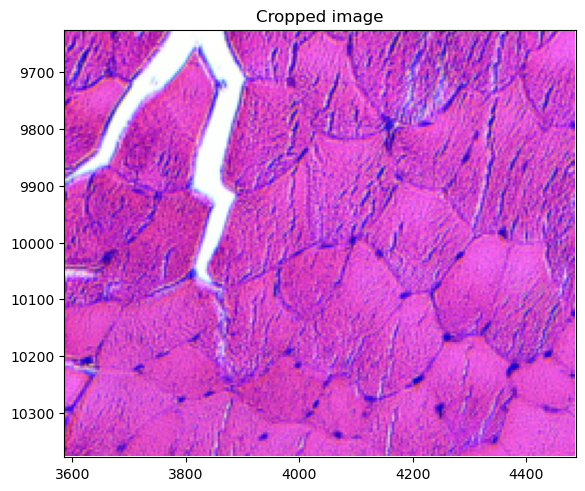

In [57]:
#show the cropped data
sdata_cropped.pl.render_images("blocco1_hires_image").pl.show(coordinate_systems = "blocco1", title="Cropped image")

# Data Normalization and Dimensionality Reduction
Normalize data in order to prevent tecnical errror (low capture efficency of a bin, different sequencing depth).
In this analysis, we set the target_sum to None, so that after normalization, each cell segmentation bin has a total UMI count equal to the median of the total UMI count for all cell segmentation bins before normalization. 

In [59]:
import scanpy as sc

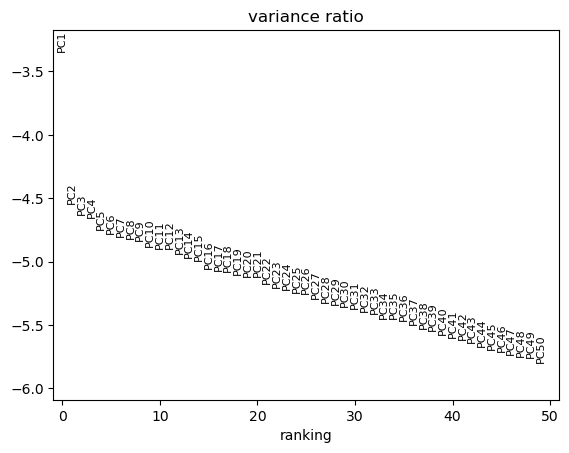

In [60]:
adata = sdata_cropped["square_008um"] 
sc.pp.normalize_total(adata, target_sum=None)
sc.pp.log1p(adata)
sc.tl.pca(adata)

#elbow plt
sc.pl.pca_variance_ratio(adata, log=True, n_pcs = 50)